In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('..').resolve().parent))
from config.preprocess_config import T
from evaluate.micro_cond import adherence_table

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [2]:
# Plot config
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'
MODEL_COLORS = {'ca': C_GEN_CA, 'ca-film': C_GEN_CAFILM}
MODEL_LABELS = {'ca': 'CA', 'ca-film': 'CA-Film'}

print("Plot config defined.")

Plot config defined.


In [3]:
"""
Get generated data.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}

ALL_FILES = sorted(f.name for f in next(iter(MODEL_DIRS.values())).glob('*.json'))

gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for filename in ALL_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        samples = np.array(payload['samples'], dtype=np.float64)
        t_tgt = payload['conditions']['trend']
        r_tgt = payload['conditions']['realized_vol']
        mean_w = t_tgt / (100.0 * T)
        var_w = (r_tgt / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
        std_w = np.sqrt(np.maximum(var_w, 1e-12))
        samples = samples * std_w + mean_w

        gen_data[model][filename] = {
            'n_samples': samples.shape[0],
            'trend_target': t_tgt,
            'trend_achieved': np.sum(samples * 100, axis=1),
            'rv_target': r_tgt,
            'rv_achieved': np.sum((samples * 100) ** 2, axis=1),
        }

print("Generated data loaded.")


Generated data loaded.


In [4]:
"""
3.1 - Trend adherence.
"""

print(f"{'=' * 25} Trend Adherence {'=' * 26}\n")
trend_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('trend', model, gen_data, ALL_FILES)
    trend_pts[model] = (targets, mean_achieved)
    print()


========================= Trend Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r100i0v40.json        -10.00     -9.8302      2.1392      0.1698
t-10r100i1v15.json        -10.00     -9.8966      3.9354      0.1034
t-10r300i0v40.json        -10.00     -9.7566      3.3699      0.2434
t-10r300i1v15.json        -10.00     -9.7387      6.1326      0.2613
t-10r500i0v40.json        -10.00     -9.5474     21.0284      0.4526
t-10r500i1v15.json        -10.00     -9.8310      8.7755      0.1690
t-10r700i0v40.json        -10.00     -9.4897      7.7790      0.5103
t-10r700i1v15.json        -10.00     -9.6116     13.8822      0.3884
t-10r900i0v40.json        -10.00     -9.7905      9.0653      0.2095
t-10r900i1v15.json        -10.00     -9.6836      8.0453      0.3164
t-20r100i0v40.json        -20.00    -19.9197      6.1074      0.0803
t-20r100i1v15.json        -20.00 

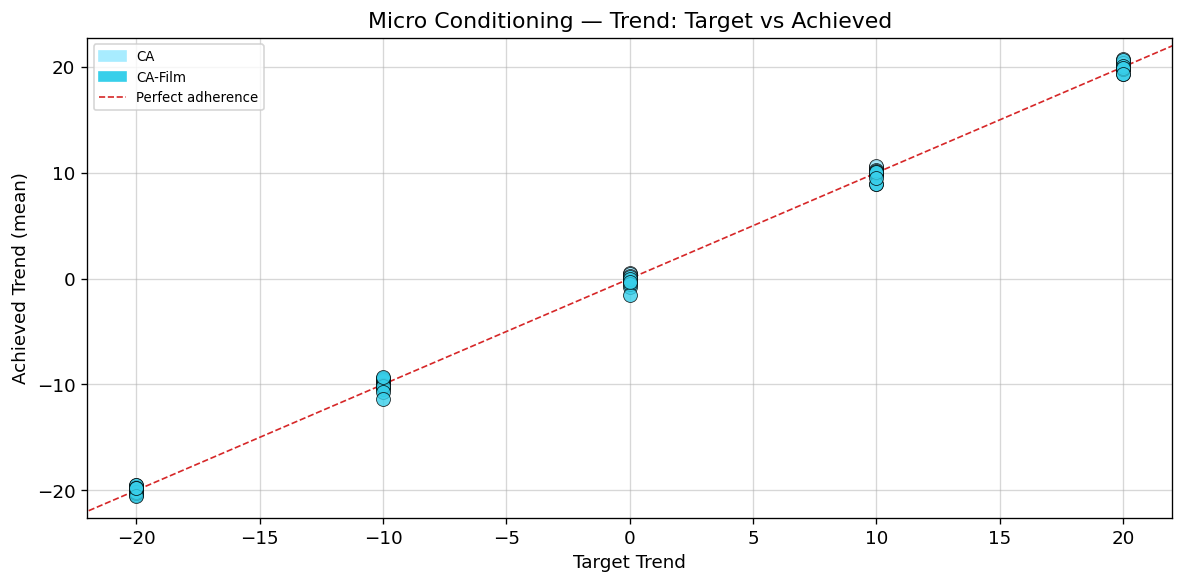

In [5]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in trend_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Trend')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Trend (mean)')
ax.set_title('Micro Conditioning — Trend: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_trend.png')
plt.show()


In [6]:
"""
3.2 - Realized volatility adherence.
"""

print(f"{'=' * 25} Realized Vol Adherence {'=' * 26}\n")
rv_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('rv', model, gen_data, ALL_FILES)
    rv_pts[model] = (targets, mean_achieved)
    print()


========================= Realized Vol Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r100i0v40.json        100.00     93.2036     37.6201      6.7964
t-10r100i1v15.json        100.00     97.8190    137.3935      2.1810
t-10r300i0v40.json        300.00    280.6343    126.3537     19.3657
t-10r300i1v15.json        300.00    286.4248    422.7347     13.5752
t-10r500i0v40.json        500.00    516.3096   3237.6332     16.3096
t-10r500i1v15.json        500.00    484.2074    757.3532     15.7926
t-10r700i0v40.json        700.00    656.1071    361.1741     43.8929
t-10r700i1v15.json        700.00    708.5706   2212.9522      8.5706
t-10r900i0v40.json        900.00    855.1764    734.4626     44.8236
t-10r900i1v15.json        900.00    839.5020    362.2301     60.4980
t-20r100i0v40.json        100.00     97.1765    231.4110      2.8235
t-20r100i1v15.json        

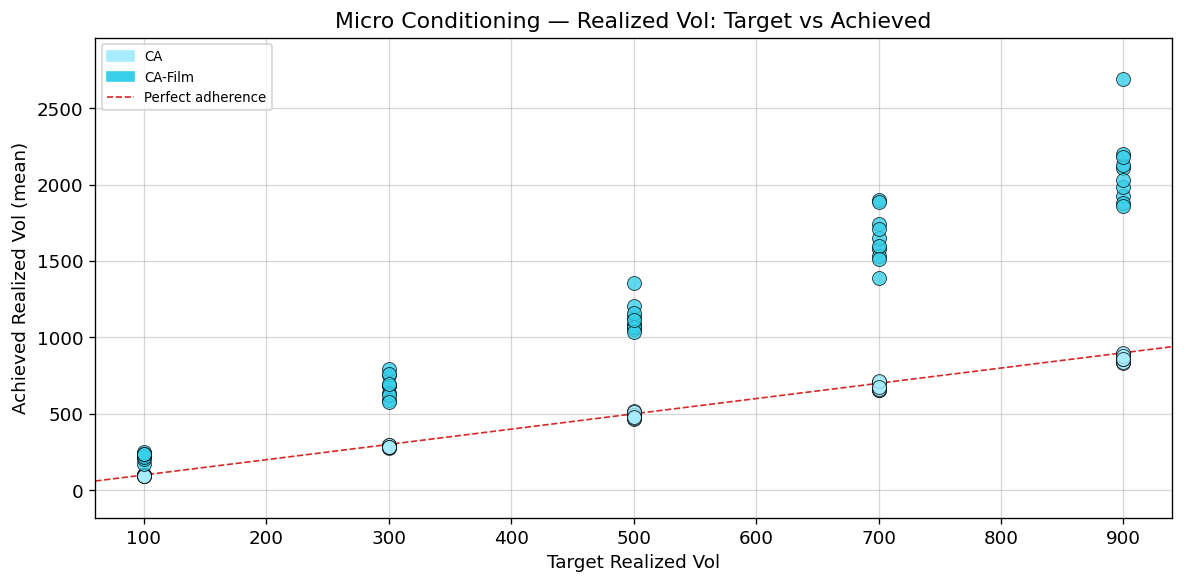

In [7]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in rv_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Realized Vol')
ax.set_ylabel('Achieved Realized Vol (mean)')
ax.set_title('Micro Conditioning — Realized Vol: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_rv.png')
plt.show()
